In [1]:
!pip -q install earthaccess tobac antimeridian

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
import antimeridian
import xarray as xr
import earthaccess

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
auth = earthaccess.login(persist=True)

In [4]:
result = earthaccess.search_datasets(
    keyword="imerghh"
)

In [5]:
[r.summary() for r in result]

/tmp/ipykernel_449/1491378410.py:1: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  [r.summary() for r in result]
/tmp/ipykernel_449/1491378410.py:1: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  [r.summary() for r in result]


[{'short-name': 'GPM_3IMERGHH',
  'concept-id': 'C2723754847-GES_DISC',
  'version': '07',
  'file-type': '',
  'get-data': ['https://gpm1.gesdisc.eosdis.nasa.gov/data/GPM_L3/GPM_3IMERGHH.07/',
   'https://search.earthdata.nasa.gov/search/granules?p=C2723754847-GES_DISC'],
  'cloud-info': {'Region': 'us-west-2',
   'S3CredentialsAPIEndpoint': 'https://data.gesdisc.earthdata.nasa.gov/s3credentials',
   'S3CredentialsAPIDocumentationURL': 'https://data.gesdisc.earthdata.nasa.gov/s3credentialsREADME',
   'S3BucketAndObjectPrefixNames': ['s3://gesdisc-cumulus-prod-protected/GPM_L3/GPM_3IMERGHH.07/']}},
 {'short-name': 'GPM_3IMERGDF',
  'concept-id': 'C2723754864-GES_DISC',
  'version': '07',
  'file-type': '',
  'get-data': ['https://gpm1.gesdisc.eosdis.nasa.gov/data/GPM_L3/GPM_3IMERGDF.07/',
   'https://search.earthdata.nasa.gov/search/granules?p=C2723754864-GES_DISC'],
  'cloud-info': {'Region': 'us-west-2',
   'S3CredentialsAPIEndpoint': 'https://data.gesdisc.earthdata.nasa.gov/s3creden

In [6]:
results = earthaccess.search_data(
    short_name="GPM_3IMERGHH", 
    temporal=("2024-08-18", "2024-08-18"),
)

/opt/conda/lib/python3.12/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [7]:
fileobjects = earthaccess.open(results)

/opt/conda/lib/python3.12/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 48/48 [00:00<00:00, 11115.65it/s]
PROCESSING TASKS | : 100%|██████████| 48/48 [00:16<00:00,  2.99it/s]
COLLECTING RESULTS | : 100%|██████████| 48/48 [00:00<00:00, 393985.50it/s]


In [8]:
imerg_ds = xr.open_mfdataset(fileobjects, group="Grid", combine="nested", concat_dim="time")

In [9]:
imerg_ds

<xarray.Dataset> Size: 5GB
Dimensions:                         (time: 48, nv: 2, lon: 3600, lonv: 2,
                                     lat: 1800, latv: 2)
Coordinates:
  * time                            (time) object 384B 2024-08-18 00:00:00 .....
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float32 7kB -89.95 -89.85 ... 89.95
Dimensions without coordinates: nv, lonv, latv
Data variables:
    time_bnds                       (time, nv) object 768B dask.array<chunksize=(1, 2), meta=np.ndarray>
    lon_bnds                        (time, lon, lonv) float32 1MB dask.array<chunksize=(1, 3600, 2), meta=np.ndarray>
    lat_bnds                        (time, lat, latv) float32 691kB dask.array<chunksize=(1, 1800, 2), meta=np.ndarray>
    precipitation                   (time, lon, lat) float32 1GB dask.array<chunksize=(1, 145, 1800), meta=np.ndarray>
    randomError                     (time, lon, lat) float32 1GB dask.array<chunksize=(1, 145, 1800), meta=np.ndarray>
    probabilityLiquidPrecipitation  (time, lon, lat) float32 1GB dask.array<chunksize=(1, 291, 1800), meta=np.ndarray>
    precipitationQualityIndex       (time, lon, lat) float32 1GB dask.array<chunksize=(1, 145, 1800), meta=np.ndarray>
Attributes:
    GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegistration=CENTER;\nLatitudeRe...

In [10]:
import tobac

/opt/conda/lib/python3.12/site-packages/tobac/utils/decorators.py:536: UserWarning: Numba not able to be imported; periodic boundary calculations will be slower.Exception raised: ModuleNotFoundError("No module named 'numba'")
  warnings.warn(


In [11]:
labels, features = tobac.feature_detection_multithreshold(
    imerg_ds.precipitation.sel(lat=slice(-45, 45)), 
    dxy=11100, 
    threshold=[5, 10],
    return_labels=True
)

Text(0, 0.5, 'Latitude')

/opt/conda/lib/python3.12/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


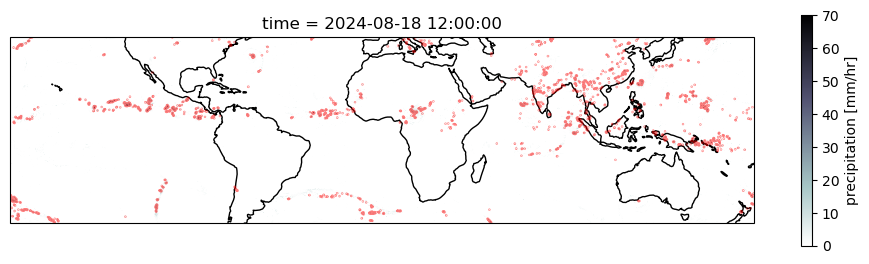

In [92]:
fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()), figsize=(12,3))

imerg_ds.precipitation.sel(lat=slice(-45, 45))[24].T.plot(ax=ax, cmap="bone_r")
ax.contour(labels.lon, labels.lat, labels[24].T, [0.5], colors="r", alpha=0.5)
ax.coastlines()
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

In [88]:
labels

<xarray.DataArray 'label_fields' (time: 48, lon: 3600, lat: 900)> Size: 1GB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
...
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(48, 3600, 900))
Coordinates:
  * time     (time) object 384B 2024-08-18 00:00:00 ... 2024-08-18 23:30:00
  * lon      (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.8 179.9
  * lat      (lat) float32 4kB -44.95 -44.85 -44.75 -44.65 ... 44.75 44.85 44.95
Attributes:
    threshold:  [5, 10]

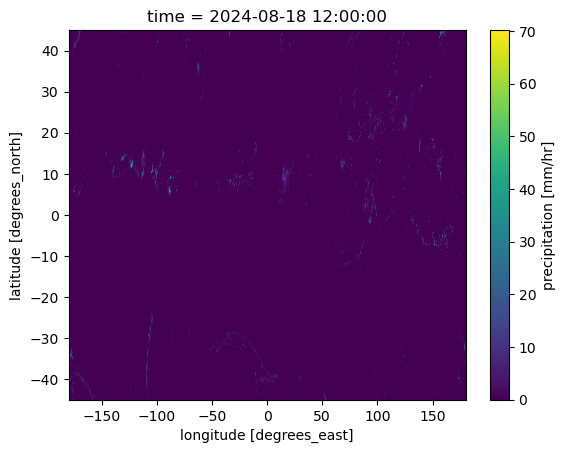

In [12]:
imerg_ds.precipitation[24].sel(lat=slice(-45, 45)).T.plot()

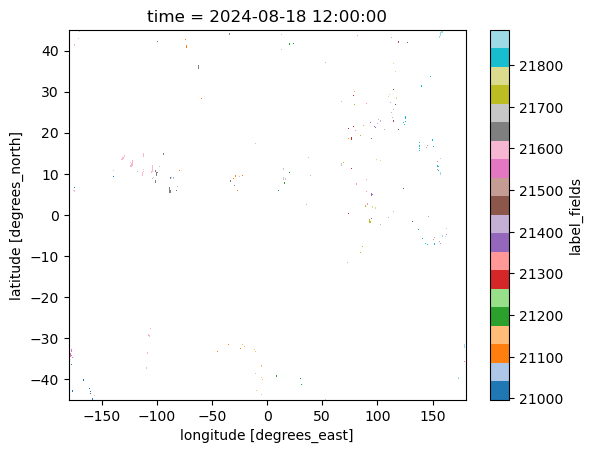

In [13]:
labels[24].where(labels[24]!=0).T.plot(cmap="tab20")

In [14]:
xr.Dataset.from_dataframe(features)

<xarray.Dataset> Size: 4MB
Dimensions:          (index: 43119)
Coordinates:
  * index            (index) int64 345kB 0 1 2 3 4 ... 43115 43116 43117 43118
Data variables:
    frame            (index) int64 345kB 0 0 0 0 0 0 0 ... 47 47 47 47 47 47 47
    idx              (index) int64 345kB 1 2 4 5 6 ... 1133 1134 1135 1136 1137
    hdim_1           (index) float64 345kB 0.0 0.0 9.125 ... 3.591e+03 3.597e+03
    hdim_2           (index) float64 345kB 107.5 139.0 102.5 ... 517.0 485.6
    num              (index) int64 345kB 2 1 8 2 6 6 6 3 4 ... 2 1 8 44 32 1 1 9
    threshold_value  (index) int64 345kB 5 5 5 5 5 5 5 ... 10 10 10 10 10 10 10
    feature          (index) int64 345kB 1 2 3 4 5 ... 43116 43117 43118 43119
    time             (index) object 345kB 2024-08-18 00:00:00 ... 2024-08-18 ...
    timestr          (index) object 345kB '2024-08-18 00:00:00' ... '2024-08-...
    lon              (index) float64 345kB -179.9 -179.9 -179.0 ... 179.1 179.8
    lat              (index) float64 345kB -34.2 -31.05 -34.7 ... 6.75 3.606

In [15]:
features_dt = xr.DataTree(
    children=dict(
        labels=xr.DataTree(labels.to_dataset()), 
        features=xr.DataTree(xr.Dataset.from_dataframe(features))
    )
)

In [16]:
import pathlib

In [17]:
save_path = pathlib.Path.home() / "my-public-bucket" / "orcestra" / "features"
save_path.mkdir(exist_ok=True, parents=True)

In [18]:
features_dt.to_netcdf(save_path / "detected_features_test.nc")

In [19]:
dates = pd.date_range(
    pd.Timestamp(year=2024,month=8,day=10), 
    pd.Timestamp(year=2024,month=10,day=1),
    freq="1d"
)

In [20]:
for start_date, end_date in zip(dates, dates[1:]):
    pass

In [21]:
start_date.strftime("%Y%m%d")

'20240930'

In [22]:
!pip -q install contourpy

In [23]:
import contourpy

In [24]:
masked_labels = np.ma.array(
    labels, mask=labels<=0
)

In [25]:
import matplotlib.pyplot as plt

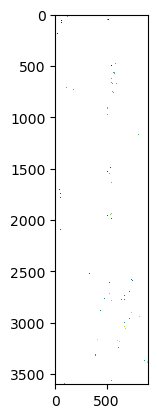

In [26]:
plt.imshow(masked_labels[24], interpolation="nearest")

In [27]:
x, y = np.meshgrid(np.arange(7), np.arange(6))

In [28]:
x.shape

(6, 7)

In [29]:
masked_labels[24].shape

(3600, 900)

In [30]:
y, x = np.meshgrid(
    *(range(s) for s in masked_labels[24].shape), indexing="ij"
)

In [31]:
contourpy.contour_generator(
    y, x, masked_labels[24], corner_mask=True
)

In [32]:
contourpy.contour_generator(
    z=labels[24], corner_mask=True
).lines(1)[0]

array([[115.00004636,   3.        ],
       [116.        ,   2.00004636],
       [117.        ,   2.00004636],
       [118.        ,   2.00004636],
       [118.99995364,   3.        ],
       [119.        ,   3.00004636],
       [120.        ,   3.00004636],
       [121.        ,   3.00004636],
       [121.99995364,   4.        ],
       [121.        ,   4.99995364],
       [120.        ,   4.99995364],
       [119.        ,   4.99995364],
       [118.        ,   4.99995364],
       [117.99995364,   5.        ],
       [117.99995364,   6.        ],
       [117.99995364,   7.        ],
       [117.        ,   7.99995364],
       [116.99995364,   8.        ],
       [117.        ,   8.00004636],
       [117.99995364,   9.        ],
       [117.        ,   9.99995364],
       [116.99995364,  10.        ],
       [116.        ,  10.99995364],
       [115.        ,  10.99995364],
       [114.99995364,  11.        ],
       [114.99995364,  12.        ],
       [114.        ,  12.99995364],
 

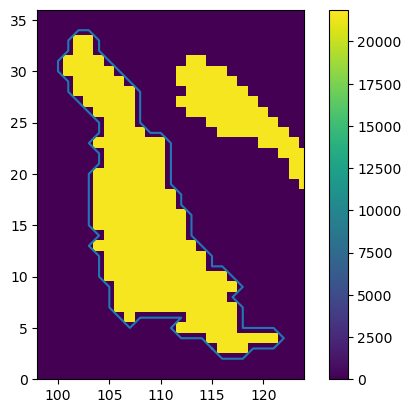

In [33]:
plt.imshow(labels[24])
plt.plot(*contourpy.contour_generator(
    z=labels[24], corner_mask=False
).lines(1)[0].T)

plt.xlim([98,124])
plt.ylim([0,36])
plt.colorbar()

In [34]:
contourpy.contour_generator(
    z=labels[24], corner_mask=False
).lines(1)[0].shape

(117, 2)

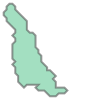

In [35]:
shapely.Polygon(contourpy.contour_generator(
    z=labels[24], corner_mask=False
).lines(1)[0])

In [36]:
contourpy.contour_generator(
    z=labels[24], corner_mask=False
).filled(0.5, np.inf)[0][0].shape

(117, 2)

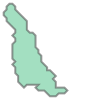

In [37]:
shapely.Polygon(contourpy.contour_generator(
    z=labels[24], corner_mask=False
).filled(0.5, np.inf)[0][0])

In [38]:
labels[24].shape

(3600, 900)

In [39]:
contour_polys = gpd.GeoDataFrame(
    data = [],
    geometry=[
        shapely.Polygon(s[...,::-1])
        for s in contourpy.contour_generator(
            x=imerg_ds.lat[450:-450], y=imerg_ds.lon, z=labels[24],
        ).lines(0.5)
    ],
    crs="EPSG:4326"
)

<Axes: >

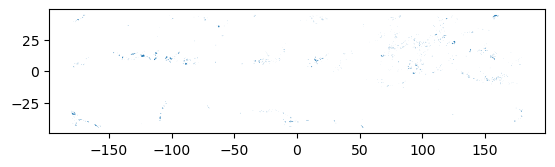

In [40]:
contour_polys.plot()

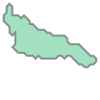

In [41]:
contour_polys.geometry[0]

In [42]:
contour_polys

,geometry
0,"POLYGON ((-179.64999 -33.45, -179.75 -33.35, -..."
1,"POLYGON ((-179.64999 -32.05, -179.75 -31.95, -..."
2,"POLYGON ((-179.55 -31.65, -179.64999 -31.55, -..."
3,"POLYGON ((-179.14999 -37.85, -179.25 -37.75, -..."
4,"POLYGON ((-178.84999 -41.75, -178.94999 -41.65..."
...,...
897,"POLYGON ((178.25 5.15, 178.15 5.25, 178.25 5.3..."
898,"POLYGON ((178.55 -31.65, 178.45 -31.55, 178.55..."
899,"POLYGON ((178.75 -35.75, 178.65 -35.65, 178.65..."
900,"POLYGON ((179.25 10.95, 179.15 11.05, 179.25 1..."


In [43]:
features_gdf = gpd.GeoDataFrame(
    features, 
    geometry = [
        shapely.Point([lon, lat])
        for lon, lat in zip(features.lon, features.lat)
    ], 
    crs="EPSG:4326"
)

In [44]:
features_gdf[features_gdf.frame==24]

,frame,idx,hdim_1,hdim_2,num,threshold_value,feature,time,timestr,lon,lat,geometry
20996,24,3,4.666667,129.000000,9,5,20997,2024-08-18 12:00:00,2024-08-18 12:00:00,-179.483332,-32.049999,POINT (-179.48333 -32.05)
20997,24,4,8.000000,72.500000,2,5,20998,2024-08-18 12:00:00,2024-08-18 12:00:00,-179.149994,-37.699999,POINT (-179.14999 -37.7)
20998,24,5,12.000000,32.333333,3,5,20999,2024-08-18 12:00:00,2024-08-18 12:00:00,-178.750000,-41.716666,POINT (-178.75 -41.71667)
20999,24,6,19.181818,486.045455,22,5,21000,2024-08-18 12:00:00,2024-08-18 12:00:00,-178.031820,3.654545,POINT (-178.03182 3.65455)
21000,24,7,17.000000,848.500000,2,5,21001,2024-08-18 12:00:00,2024-08-18 12:00:00,-178.250000,39.900000,POINT (-178.25 39.9)
...,...,...,...,...,...,...,...,...,...,...,...,...
21879,24,1114,3575.000000,554.000000,1,10,21880,2024-08-18 12:00:00,2024-08-18 12:00:00,177.550003,10.450000,POINT (177.55 10.45)
21880,24,1115,3576.000000,146.500000,2,10,21881,2024-08-18 12:00:00,2024-08-18 12:00:00,177.649994,-30.299999,POINT (177.64999 -30.3)
21881,24,1116,3577.500000,142.500000,4,10,21882,2024-08-18 12:00:00,2024-08-18 12:00:00,177.799995,-30.700000,POINT (177.8 -30.7)
21882,24,1117,3580.000000,143.000000,1,10,21883,2024-08-18 12:00:00,2024-08-18 12:00:00,178.050003,-30.650000,POINT (178.05 -30.65)


In [45]:
(~gpd.sjoin(features_gdf[features_gdf.frame==24], contour_polys).index_right.isin(contour_polys.index)).sum()

np.int64(0)

In [46]:
contains = contour_polys.sjoin(contour_polys, predicate="contains")

In [47]:
contour_polys.loc[
    contains.index_right[contains.index != contains.index_right]
]

,geometry
52,"POLYGON ((-160.45 -43.35, -160.45 -43.35, -160..."
64,"POLYGON ((-141.84999 12.95, -141.84999 12.95, ..."
112,"POLYGON ((-105.85 -27.75, -105.85 -27.75, -105..."
179,"POLYGON ((-62.85 35.95, -62.85 35.95, -62.85 3..."
330,"POLYGON ((17.85 10.35, 17.85 10.35, 17.85 10.3..."
382,"POLYGON ((52.55 -44.65, 52.55 -44.65, 52.55 -4..."
398,"POLYGON ((67.25 12.35, 67.25 12.35, 67.25 12.3..."
565,"POLYGON ((94.85 4.85, 94.85 4.85, 94.94999 4.7..."
744,"POLYGON ((138.14999 16.95, 138.14999 16.95, 13..."
746,"POLYGON ((138.34999 17.05, 138.34999 17.05, 13..."


In [48]:
contour_polys.loc[
    ~contour_polys.index.isin(gpd.sjoin(features_gdf[features_gdf.frame==24], contour_polys).index_right)
]

,geometry
52,"POLYGON ((-160.45 -43.35, -160.45 -43.35, -160..."
64,"POLYGON ((-141.84999 12.95, -141.84999 12.95, ..."
112,"POLYGON ((-105.85 -27.75, -105.85 -27.75, -105..."
179,"POLYGON ((-62.85 35.95, -62.85 35.95, -62.85 3..."
382,"POLYGON ((52.55 -44.65, 52.55 -44.65, 52.55 -4..."
398,"POLYGON ((67.25 12.35, 67.25 12.35, 67.25 12.3..."
565,"POLYGON ((94.85 4.85, 94.85 4.85, 94.94999 4.7..."
744,"POLYGON ((138.14999 16.95, 138.14999 16.95, 13..."
746,"POLYGON ((138.34999 17.05, 138.34999 17.05, 13..."
785,"POLYGON ((151.64999 -7.05, 151.64999 -7.05, 15..."


In [49]:
contour_polys.sjoin_nearest(features_gdf[features_gdf.frame==24])

/opt/conda/lib/python3.12/site-packages/geopandas/array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,geometry,index_right,frame,idx,hdim_1,hdim_2,num,threshold_value,feature,time,timestr,lon,lat
0,"POLYGON ((-179.64999 -33.45, -179.75 -33.35, -...",21567,24,802,15.668224,108.813084,214,10,21568,2024-08-18 12:00:00,2024-08-18 12:00:00,-178.383170,-34.068691
1,"POLYGON ((-179.64999 -32.05, -179.75 -31.95, -...",20996,24,3,4.666667,129.000000,9,5,20997,2024-08-18 12:00:00,2024-08-18 12:00:00,-179.483332,-32.049999
2,"POLYGON ((-179.55 -31.65, -179.64999 -31.55, -...",21568,24,803,4.000000,134.000000,1,10,21569,2024-08-18 12:00:00,2024-08-18 12:00:00,-179.550003,-31.549999
3,"POLYGON ((-179.14999 -37.85, -179.25 -37.75, -...",20997,24,4,8.000000,72.500000,2,5,20998,2024-08-18 12:00:00,2024-08-18 12:00:00,-179.149994,-37.699999
4,"POLYGON ((-178.84999 -41.75, -178.94999 -41.65...",20998,24,5,12.000000,32.333333,3,5,20999,2024-08-18 12:00:00,2024-08-18 12:00:00,-178.750000,-41.716666
...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,"POLYGON ((178.25 5.15, 178.15 5.25, 178.25 5.3...",21563,24,796,3583.200000,502.400000,5,5,21564,2024-08-18 12:00:00,2024-08-18 12:00:00,178.369992,5.290000
898,"POLYGON ((178.55 -31.65, 178.45 -31.55, 178.55...",21883,24,1118,3589.209302,131.581395,43,10,21884,2024-08-18 12:00:00,2024-08-18 12:00:00,178.970928,-31.791860
899,"POLYGON ((178.75 -35.75, 178.65 -35.65, 178.65...",21564,24,798,3591.740741,91.777778,27,5,21565,2024-08-18 12:00:00,2024-08-18 12:00:00,179.224072,-35.772222
900,"POLYGON ((179.25 10.95, 179.15 11.05, 179.25 1...",21565,24,799,3592.000000,560.000000,1,5,21566,2024-08-18 12:00:00,2024-08-18 12:00:00,179.250000,11.050000


In [50]:
features_gdf[features_gdf.frame==24].sjoin_nearest(contour_polys)

/opt/conda/lib/python3.12/site-packages/geopandas/array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,frame,idx,hdim_1,hdim_2,num,threshold_value,feature,time,timestr,lon,lat,geometry,index_right
20996,24,3,4.666667,129.000000,9,5,20997,2024-08-18 12:00:00,2024-08-18 12:00:00,-179.483332,-32.049999,POINT (-179.48333 -32.05),1
20997,24,4,8.000000,72.500000,2,5,20998,2024-08-18 12:00:00,2024-08-18 12:00:00,-179.149994,-37.699999,POINT (-179.14999 -37.7),3
20998,24,5,12.000000,32.333333,3,5,20999,2024-08-18 12:00:00,2024-08-18 12:00:00,-178.750000,-41.716666,POINT (-178.75 -41.71667),4
20999,24,6,19.181818,486.045455,22,5,21000,2024-08-18 12:00:00,2024-08-18 12:00:00,-178.031820,3.654545,POINT (-178.03182 3.65455),6
21000,24,7,17.000000,848.500000,2,5,21001,2024-08-18 12:00:00,2024-08-18 12:00:00,-178.250000,39.900000,POINT (-178.25 39.9),7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21879,24,1114,3575.000000,554.000000,1,10,21880,2024-08-18 12:00:00,2024-08-18 12:00:00,177.550003,10.450000,POINT (177.55 10.45),892
21880,24,1115,3576.000000,146.500000,2,10,21881,2024-08-18 12:00:00,2024-08-18 12:00:00,177.649994,-30.299999,POINT (177.64999 -30.3),893
21881,24,1116,3577.500000,142.500000,4,10,21882,2024-08-18 12:00:00,2024-08-18 12:00:00,177.799995,-30.700000,POINT (177.8 -30.7),894
21882,24,1117,3580.000000,143.000000,1,10,21883,2024-08-18 12:00:00,2024-08-18 12:00:00,178.050003,-30.650000,POINT (178.05 -30.65),895


<Axes: >

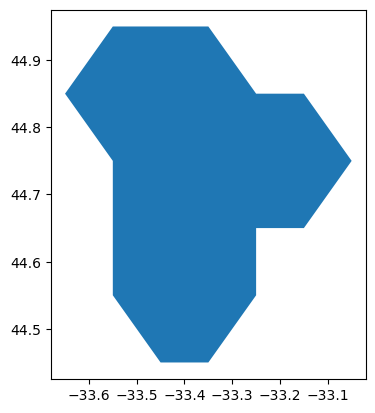

In [51]:
contour_polys.iloc[196:197].plot()

In [52]:
from pystac_client import Client

catalog_url = 'https://catalog.maap.eo.esa.int/catalogue/'
catalog = Client.open(catalog_url)
EC_COLLECTION = ['EarthCAREL2Validated_MAAP']

import pathlib
import requests
import fsspec

CREDENTIALS_FILE = (pathlib.Path.home() / "credentials.txt" ).resolve()   # Insert the .txt path
io_params = {
    "fsspec_params": {
        "cache_type": "blockcache",
        "block_size": 8 * 1024 * 1024
    },
    "h5py_params": {
        "driver_kwds": {
            "rdcc_nbytes": 8 * 1024 * 1024
        }
    }
}

def load_credentials(file_path=CREDENTIALS_FILE):
    """Read key-value pairs from a credentials file into a dictionary."""
    creds = {}
    if not file_path.exists():
        raise FileNotFoundError(f"Credentials file not found: {file_path}")
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "=" not in line:
                continue
            key, value = line.split("=", 1)
            creds[key.strip()] = value.strip()
    return creds


# --- ESA MAAP API ---

def get_token():
    """Use OFFLINE_TOKEN to fetch a short-lived access token."""
    creds = load_credentials()

    OFFLINE_TOKEN = creds.get("OFFLINE_TOKEN")
    CLIENT_ID = creds.get("CLIENT_ID")
    CLIENT_SECRET = creds.get("CLIENT_SECRET")
    # print(CLIENT_SECRET)

    if not all([OFFLINE_TOKEN, CLIENT_ID, CLIENT_SECRET]):
        raise ValueError("Missing OFFLINE_TOKEN, CLIENT_ID, or CLIENT_SECRET in credentials file")

    url = "https://iam.maap.eo.esa.int/realms/esa-maap/protocol/openid-connect/token"
    data = {
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET,
        "grant_type": "refresh_token",
        "refresh_token": OFFLINE_TOKEN,
        "scope": "offline_access openid"
    }

    response = requests.post(url, data=data)
    response.raise_for_status()

    response_json = response.json()
    access_token = response_json.get('access_token')

    if not access_token:
        raise RuntimeError("Failed to retrieve access token from IAM response")

    return access_token

token = get_token()
fs = fsspec.filesystem(
    "https", 
    headers={"Authorization": f"Bearer {token}"}, 
    **io_params["fsspec_params"], 
)

from contextlib import contextmanager

@contextmanager
def read_ec_file(filename):
    try:
        f = fs.open(filename)
        ds = xr.open_dataset(
            f, 
            engine="h5netcdf", 
            **io_params["h5py_params"],  
            group="ScienceData"
        )
        yield ds
    finally:
        f.close()
        ds.close()


In [53]:
search = catalog.search(
    collections=EC_COLLECTION, 
    datetime=("2024-08-18", "2024-08-18"), 
    filter="(productType = 'ACM_CAP_2B')", #"(productType = 'CPR_FMR_2A')",# or (productType = 'CPR_CD__2A')",
    method = 'GET', # This is necessary 
)

df = pd.DataFrame(
    data={"stac":list(search.items())}
)

df["granule"] = [f.id[-6:] for f in df.stac]
df["product"] = [f.id[9:19] for f in df.stac]
df["baseline"] = [f.id[6:8] for f in df.stac]
df["date"] = [
    pd.to_datetime(f.id[20:35], format="%Y%m%dT%H%M%S") for f in df.stac
]
df["start_time"] = [
    pd.Timestamp(f.properties["start_datetime"][:-1]) for f in df.stac
]
df["end_time"] = [
    pd.Timestamp(f.properties["end_datetime"][:-1]) for f in df.stac
]
df["enclosure_h5"] = [f.assets.get('enclosure_h5').href for f in df.stac]
df = df.sort_values(["date", "product"]).reset_index(drop=True)

In [54]:
df

,stac,granule,product,baseline,date,start_time,end_time,enclosure_h5
0,<Item id=ECA_EXBA_ACM_CAP_2B_20240817T235933Z_...,01261B,ACM_CAP_2B,BA,2024-08-17 23:59:33,2024-08-17 23:59:33,2024-08-18 00:11:20,https://catalog.maap.eo.esa.int/data/earthcare...
1,<Item id=ECA_EXBA_ACM_CAP_2B_20240818T001120Z_...,01261C,ACM_CAP_2B,BA,2024-08-18 00:11:20,2024-08-18 00:11:20,2024-08-18 00:22:25,https://catalog.maap.eo.esa.int/data/earthcare...
2,<Item id=ECA_EXBA_ACM_CAP_2B_20240818T003412Z_...,01261E,ACM_CAP_2B,BA,2024-08-18 00:34:12,2024-08-18 00:34:12,2024-08-18 00:45:47,https://catalog.maap.eo.esa.int/data/earthcare...
3,<Item id=ECA_EXBA_ACM_CAP_2B_20240818T004547Z_...,01261F,ACM_CAP_2B,BA,2024-08-18 00:45:47,2024-08-18 00:45:47,2024-08-18 00:57:36,https://catalog.maap.eo.esa.int/data/earthcare...
4,<Item id=ECA_EXBA_ACM_CAP_2B_20240818T005736Z_...,01261G,ACM_CAP_2B,BA,2024-08-18 00:57:36,2024-08-18 00:57:36,2024-08-18 01:08:43,https://catalog.maap.eo.esa.int/data/earthcare...
...,...,...,...,...,...,...,...,...
119,<Item id=ECA_EXBA_ACM_CAP_2B_20240818T230810Z_...,01276B,ACM_CAP_2B,BA,2024-08-18 23:08:10,2024-08-18 23:08:10,2024-08-18 23:19:57,https://catalog.maap.eo.esa.int/data/earthcare...
120,<Item id=ECA_EXBA_ACM_CAP_2B_20240818T231957Z_...,01276C,ACM_CAP_2B,BA,2024-08-18 23:19:57,2024-08-18 23:19:57,2024-08-18 23:31:02,https://catalog.maap.eo.esa.int/data/earthcare...
121,<Item id=ECA_EXBA_ACM_CAP_2B_20240818T233102Z_...,01276D,ACM_CAP_2B,BA,2024-08-18 23:31:02,2024-08-18 23:31:02,2024-08-18 23:42:49,https://catalog.maap.eo.esa.int/data/earthcare...
122,<Item id=ECA_EXBA_ACM_CAP_2B_20240818T234249Z_...,01276E,ACM_CAP_2B,BA,2024-08-18 23:42:49,2024-08-18 23:42:49,2024-08-18 23:54:24,https://catalog.maap.eo.esa.int/data/earthcare...


In [55]:
def fix_coords(stac_item):
    if (
        (stac_item.properties["product:type"].startswith("CPR"))
        & (stac_item.properties["sat:absolute_orbit"] < 7835) 
        & (stac_item.id[-1] in "DEFGH")
    ):
        coords = np.array(stac_item.geometry["coordinates"]) + np.array([[23,0]])
        if np.any(wh:=(coords[:,0]>180)):
            coords[wh,0]-=360
    else:
        coords = np.array(stac_item.geometry["coordinates"])

    return antimeridian.fix_line_string(
        shapely.LineString(coords), 
        great_circle=True,
    )
 

In [56]:
gdf = gpd.GeoDataFrame(
    df.drop("stac", axis=1), 
    geometry=[
        fix_coords(f) for f in df["stac"]
    ], 
    crs="EPSG:4326"
)

In [57]:
gdf

,granule,product,baseline,date,start_time,end_time,enclosure_h5,geometry
0,01261B,ACM_CAP_2B,BA,2024-08-17 23:59:33,2024-08-17 23:59:33,2024-08-18 00:11:20,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (27.68494 22.48209, 26.6035 27.5503..."
1,01261C,ACM_CAP_2B,BA,2024-08-18 00:11:20,2024-08-18 00:11:20,2024-08-18 00:22:25,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (10.54461 67.47265, 5.37607 71.9410..."
2,01261E,ACM_CAP_2B,BA,2024-08-18 00:34:12,2024-08-18 00:34:12,2024-08-18 00:45:47,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (-155.195 22.49107, -156.2071 17.49..."
3,01261F,ACM_CAP_2B,BA,2024-08-18 00:45:47,2024-08-18 00:45:47,2024-08-18 00:57:36,https://catalog.maap.eo.esa.int/data/earthcare...,"MULTILINESTRING ((-163.87456 -22.48694, -164.9..."
4,01261G,ACM_CAP_2B,BA,2024-08-18 00:57:36,2024-08-18 00:57:36,2024-08-18 01:08:43,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (178.93549 -67.51849, 173.74509 -71..."
...,...,...,...,...,...,...,...,...
119,01276B,ACM_CAP_2B,BA,2024-08-18 23:08:10,2024-08-18 23:08:10,2024-08-18 23:19:57,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (40.52288 22.48893, 39.44139 27.557..."
120,01276C,ACM_CAP_2B,BA,2024-08-18 23:19:57,2024-08-18 23:19:57,2024-08-18 23:31:02,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (23.37724 67.48045, 18.205 71.94881..."
121,01276D,ACM_CAP_2B,BA,2024-08-18 23:31:02,2024-08-18 23:31:02,2024-08-18 23:42:49,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (-125.19277 67.50079, -129.01086 62..."
122,01276E,ACM_CAP_2B,BA,2024-08-18 23:42:49,2024-08-18 23:42:49,2024-08-18 23:54:24,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (-142.35803 22.47775, -143.37006 17..."


Text(0, 0.5, 'Latitude')

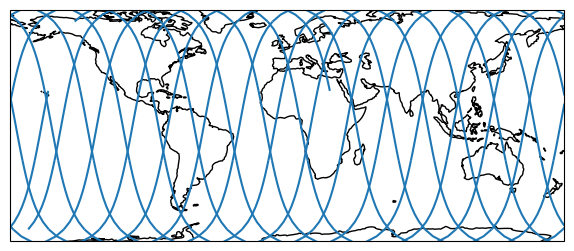

In [110]:
fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()), figsize=(12,3))
ax.coastlines()
gdf.plot(ax=ax)
ax.set_extent([-180,180,-75,75], crs=ccrs.PlateCarree())
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

In [58]:
features

,frame,idx,hdim_1,hdim_2,num,threshold_value,feature,time,timestr,lon,lat
0,0,1,0.000000,107.500000,2,5,1,2024-08-18 00:00:00,2024-08-18 00:00:00,-179.949997,-34.199999
1,0,2,0.000000,139.000000,1,5,2,2024-08-18 00:00:00,2024-08-18 00:00:00,-179.949997,-31.049999
2,0,4,9.125000,102.500000,8,5,3,2024-08-18 00:00:00,2024-08-18 00:00:00,-179.037502,-34.699999
3,0,5,12.500000,815.000000,2,5,4,2024-08-18 00:00:00,2024-08-18 00:00:00,-178.699997,36.549999
4,0,6,14.000000,524.500000,6,5,5,2024-08-18 00:00:00,2024-08-18 00:00:00,-178.550003,7.500000
...,...,...,...,...,...,...,...,...,...,...,...
43114,47,1133,3576.909091,493.568182,44,10,43115,2024-08-18 23:30:00,2024-08-18 23:30:00,177.740909,4.406818
43115,47,1134,3586.843750,493.000000,32,10,43116,2024-08-18 23:30:00,2024-08-18 23:30:00,178.734374,4.350000
43116,47,1135,3590.000000,362.000000,1,10,43117,2024-08-18 23:30:00,2024-08-18 23:30:00,179.050003,-8.750000
43117,47,1136,3591.000000,517.000000,1,10,43118,2024-08-18 23:30:00,2024-08-18 23:30:00,179.149994,6.750000


In [59]:
features_gdf = gpd.GeoDataFrame(
    features, 
    geometry = [
        antimeridian.fix_polygon(shapely.Point([lon, lat]).buffer(n**0.5))
        for lon, lat, n in zip(features.lon, features.lat, features.num)
    ], 
    crs="EPSG:4326"
)

/opt/conda/lib/python3.12/site-packages/antimeridian/_implementation.py:734: FixWindingWarning: The exterior ring of this shape is wound clockwise. Since this is a common error in real-world geometries, this package is reversing the exterior coordinates of the input shape before running its algorithm. If you know that your input shape is correct (i.e. if your data encompasses both poles), pass `fix_winding=False`. To silence this warning while keeping the fix, pass `fix_winding=True`.
  FixWindingWarning.warn()
/opt/conda/lib/python3.12/site-packages/antimeridian/_implementation.py:475: FixWindingWarning: The exterior ring of this shape is wound clockwise. Since this is a common error in real-world geometries, this package is reversing the exterior coordinates of the input shape before running its algorithm. If you know that your input shape is correct (i.e. if your data encompasses both poles), pass `fix_winding=False`. To silence this warning while keeping the fix, pass `fix_winding=

In [60]:
features_gdf

,frame,idx,hdim_1,hdim_2,num,threshold_value,feature,time,timestr,lon,lat,geometry
0,0,1,0.000000,107.500000,2,5,1,2024-08-18 00:00:00,2024-08-18 00:00:00,-179.949997,-34.199999,"MULTIPOLYGON (((-180 -35.61177, -179.95 -35.61..."
1,0,2,0.000000,139.000000,1,5,2,2024-08-18 00:00:00,2024-08-18 00:00:00,-179.949997,-31.049999,"MULTIPOLYGON (((-180 -32.04755, -179.95 -32.05..."
2,0,4,9.125000,102.500000,8,5,3,2024-08-18 00:00:00,2024-08-18 00:00:00,-179.037502,-34.699999,"MULTIPOLYGON (((-180 -37.35612, -179.85855 -37..."
3,0,5,12.500000,815.000000,2,5,4,2024-08-18 00:00:00,2024-08-18 00:00:00,-178.699997,36.549999,"MULTIPOLYGON (((-180 35.99495, -179.94722 35.8..."
4,0,6,14.000000,524.500000,6,5,5,2024-08-18 00:00:00,2024-08-18 00:00:00,-178.550003,7.500000,"MULTIPOLYGON (((-180 5.52945, -179.91087 5.463..."
...,...,...,...,...,...,...,...,...,...,...,...,...
43114,47,1133,3576.909091,493.568182,44,10,43115,2024-08-18 23:30:00,2024-08-18 23:30:00,177.740909,4.406818,"MULTIPOLYGON (((-180 -1.82149, -179.72066 -1.7..."
43115,47,1134,3586.843750,493.000000,32,10,43116,2024-08-18 23:30:00,2024-08-18 23:30:00,178.734374,4.350000,"MULTIPOLYGON (((-180 -1.15759, -179.62353 -1.0..."
43116,47,1135,3590.000000,362.000000,1,10,43117,2024-08-18 23:30:00,2024-08-18 23:30:00,179.050003,-8.750000,"MULTIPOLYGON (((-180 -9.05969, -179.99306 -9.0..."
43117,47,1136,3591.000000,517.000000,1,10,43118,2024-08-18 23:30:00,2024-08-18 23:30:00,179.149994,6.750000,"MULTIPOLYGON (((-180 6.22536, -179.96808 6.278..."


In [61]:
features_gdf["time"] = xr.CFTimeIndex(features.time).to_datetimeindex()

/tmp/ipykernel_1207/4009339037.py:1: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'julian', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  features_gdf["time"] = xr.CFTimeIndex(features.time).to_datetimeindex()


In [62]:
gdf['geometry'].is_valid.all()

np.True_

In [63]:
features_gdf['geometry'].is_valid.all()

np.True_

In [64]:
intersect_gdf = gpd.sjoin(features_gdf, gdf).loc[
    lambda d: (d.start_time<(d.time+pd.Timedelta("30m"))) & (d.end_time > d.time)
]

In [65]:
intersect_gdf

,frame,idx,hdim_1,hdim_2,num,threshold_value,feature,time,timestr,lon,lat,geometry,index_right,granule,product,baseline,date,start_time,end_time,enclosure_h5
889,1,23,74.750799,54.693291,313,5,890,2024-08-18 00:30:00,2024-08-18 00:30:00,-172.474919,-39.480671,"MULTIPOLYGON (((-180 -55.4748, -179.24528 -55....",3,01261F,ACM_CAP_2B,BA,2024-08-18 00:45:47,2024-08-18 00:45:47,2024-08-18 00:57:36,https://catalog.maap.eo.esa.int/data/earthcare...
891,1,25,96.598058,9.518447,515,5,892,2024-08-18 00:30:00,2024-08-18 00:30:00,-170.290190,-43.998155,"MULTIPOLYGON (((-180 -64.4911, -178.97466 -64....",3,01261F,ACM_CAP_2B,BA,2024-08-18 00:45:47,2024-08-18 00:45:47,2024-08-18 00:57:36,https://catalog.maap.eo.esa.int/data/earthcare...
891,1,25,96.598058,9.518447,515,5,892,2024-08-18 00:30:00,2024-08-18 00:30:00,-170.290190,-43.998155,"MULTIPOLYGON (((-180 -64.4911, -178.97466 -64....",2,01261E,ACM_CAP_2B,BA,2024-08-18 00:34:12,2024-08-18 00:34:12,2024-08-18 00:45:47,https://catalog.maap.eo.esa.int/data/earthcare...
892,1,26,78.268293,24.926829,41,5,893,2024-08-18 00:30:00,2024-08-18 00:30:00,-172.123167,-42.457318,"POLYGON ((-165.72004 -42.45732, -165.75088 -41...",3,01261F,ACM_CAP_2B,BA,2024-08-18 00:45:47,2024-08-18 00:45:47,2024-08-18 00:57:36,https://catalog.maap.eo.esa.int/data/earthcare...
896,1,31,90.800000,29.400000,5,5,897,2024-08-18 00:30:00,2024-08-18 00:30:00,-170.869992,-42.010000,"POLYGON ((-168.63392 -42.01, -168.64469 -41.79...",3,01261F,ACM_CAP_2B,BA,2024-08-18 00:45:47,2024-08-18 00:45:47,2024-08-18 00:57:36,https://catalog.maap.eo.esa.int/data/earthcare...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40043,44,900,596.000000,600.000000,5,10,40044,2024-08-18 22:00:00,2024-08-18 22:00:00,-120.349998,15.049999,"POLYGON ((-118.11393 15.05, -118.1247 15.26917...",114,01275E,ACM_CAP_2B,BA,2024-08-18 22:10:14,2024-08-18 22:10:14,2024-08-18 22:21:50,https://catalog.maap.eo.esa.int/data/earthcare...
40045,44,902,619.814815,560.259259,27,10,40046,2024-08-18 22:00:00,2024-08-18 22:00:00,-117.968515,11.075926,"POLYGON ((-112.77236 11.07593, -112.79738 11.5...",114,01275E,ACM_CAP_2B,BA,2024-08-18 22:10:14,2024-08-18 22:10:14,2024-08-18 22:21:50,https://catalog.maap.eo.esa.int/data/earthcare...
42263,47,51,199.538462,6.307692,13,5,42264,2024-08-18 23:30:00,2024-08-18 23:30:00,-159.996154,-44.319230,"POLYGON ((-156.3906 -44.31923, -156.40796 -43....",123,01276F,ACM_CAP_2B,BA,2024-08-18 23:54:24,2024-08-18 23:54:24,2024-08-19 00:06:12,https://catalog.maap.eo.esa.int/data/earthcare...
42264,47,52,331.555556,599.222222,9,5,42265,2024-08-18 23:30:00,2024-08-18 23:30:00,-146.794440,14.972222,"POLYGON ((-143.79444 14.97222, -143.80889 15.2...",122,01276E,ACM_CAP_2B,BA,2024-08-18 23:42:49,2024-08-18 23:42:49,2024-08-18 23:54:24,https://catalog.maap.eo.esa.int/data/earthcare...


In [66]:
intersect_gdf.enclosure_h5.iloc[0]

'https://catalog.maap.eo.esa.int/data/earthcare-pdgs-01/EarthCARE/ACM_CAP_2B/BA/2024/08/18/ECA_EXBA_ACM_CAP_2B_20240818T004547Z_20250905T233005Z_01261F/ECA_EXBA_ACM_CAP_2B_20240818T004547Z_20250905T233005Z_01261F/ECA_EXBA_ACM_CAP_2B_20240818T004547Z_20250905T233005Z_01261F.h5'

In [67]:
with read_ec_file(intersect_gdf.enclosure_h5.iloc[0]) as ds:
    ds = ds.load()

In [68]:
ds

<xarray.Dataset> Size: 569MB
Dimensions:                                                         (
                                                                     along_track: 5020,
                                                                     JSG_height: 242,
                                                                     MSI_longwave_channel: 3,
                                                                     MSI_shortwave_channel: 1)
Dimensions without coordinates: along_track, JSG_height, MSI_longwave_channel,
                                MSI_shortwave_channel
Data variables: (12/192)
    time                                                            (along_track) datetime64[ns] 40kB ...
    latitude                                                        (along_track) float64 40kB ...
    longitude                                                       (along_track) float64 40kB ...
    height                                                          (along_track, JSG_height) float32 5MB ...
    geoid_offset                                                    (along_track) float32 20kB ...
    elevation                                                       (along_track) float32 20kB ...
    ...                                                              ...
    MSI_shortwave_observation_variable_count                        (along_track) int32 20kB ...
    MSI_shortwave_cost_function                                     (along_track) float32 20kB ...
    MSI_shortwave_wavelength                                        (MSI_shortwave_channel) float32 4B ...
    MSI_shortwave_albedo_forward                                    (along_track, MSI_shortwave_channel) float32 20kB ...
    MSI_shortwave_albedo                                            (along_track, MSI_shortwave_channel) float32 20kB ...
    MSI_shortwave_albedo_assimilation_status                        (along_track) int8 5kB ...

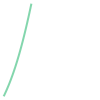

In [69]:
shapely.intersection(
    antimeridian.fix_line_string(
        shapely.LineString(zip(ds.longitude, ds.latitude)), great_circle=True
    ), 
    intersect_gdf.geometry.iloc[0]
)

In [70]:
list(shapely.intersection(
    antimeridian.fix_line_string(
        shapely.LineString(zip(ds.longitude, ds.latitude)), great_circle=True
    ), 
    intersect_gdf.geometry.iloc[0]
).coords)

[(-164.162987587229, -23.864682043597558),
 (-164.1651681714881, -23.87504732188605),
 (-164.1670410644229, -23.883949284249386),
 (-164.16891379702028, -23.892851223688552),
 (-164.17078708204534, -23.901753280433553),
 (-164.17266008640487, -23.910656403050513),
 (-164.17453328071502, -23.91955912686673),
 (-164.17640687884455, -23.92846106054828),
 (-164.17874248390083, -23.939553687575085),
 (-164.18061666269944, -23.94845507615017),
 (-164.18249040539936, -23.95735669218474),
 (-164.1843642375287, -23.966258380689595),
 (-164.18623818748338, -23.975160662828237),
 (-164.1881129710252, -23.984062375737565),
 (-164.18998807847288, -23.992964331308407),
 (-164.19232527915153, -24.004058272941002),
 (-164.19420060963967, -24.012962520241793),
 (-164.19607601444145, -24.021866147580823),
 (-164.19795180598382, -24.030770036064563),
 (-164.19982796094143, -24.039672567638384),
 (-164.2017040396447, -24.048575674892046),
 (-164.20358007246602, -24.05747981151976),
 (-164.20591498009847, 

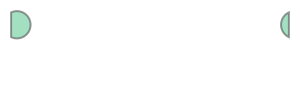

In [71]:
intersect_gdf.geometry.iloc[0]

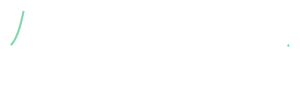

In [72]:
antimeridian.fix_line_string(
    shapely.LineString(zip(ds.longitude, ds.latitude)), great_circle=True
)

In [73]:
intersect_gdf.groupby("granule").first()

,frame,idx,hdim_1,hdim_2,num,threshold_value,feature,time,timestr,lon,lat,geometry,index_right,product,baseline,date,start_time,end_time,enclosure_h5
granule,,,,,,,,,,,,,,,,,,,
01261E,1,25,96.598058,9.518447,515,5,892,2024-08-18 00:30:00,2024-08-18 00:30:00,-170.290190,-43.998155,"MULTIPOLYGON (((-180 -64.4911, -178.97466 -64....",2,ACM_CAP_2B,BA,2024-08-18 00:34:12,2024-08-18 00:34:12,2024-08-18 00:45:47,https://catalog.maap.eo.esa.int/data/earthcare...
01261F,1,23,74.750799,54.693291,313,5,890,2024-08-18 00:30:00,2024-08-18 00:30:00,-172.474919,-39.480671,"MULTIPOLYGON (((-180 -55.4748, -179.24528 -55....",3,ACM_CAP_2B,BA,2024-08-18 00:45:47,2024-08-18 00:45:47,2024-08-18 00:57:36,https://catalog.maap.eo.esa.int/data/earthcare...
01262D,3,744,3.212121,861.257576,66,10,3164,2024-08-18 01:30:00,2024-08-18 01:30:00,-179.628784,41.175756,"MULTIPOLYGON (((-180 33.07059, -179.62878 33.0...",9,ACM_CAP_2B,BA,2024-08-18 01:55:00,2024-08-18 01:55:00,2024-08-18 02:06:46,https://catalog.maap.eo.esa.int/data/earthcare...
01262E,4,702,3552.000000,352.333333,3,5,3972,2024-08-18 02:00:00,2024-08-18 02:00:00,175.250000,-9.716667,"POLYGON ((176.98205 -9.71667, 176.97371 -9.546...",10,ACM_CAP_2B,BA,2024-08-18 02:06:46,2024-08-18 02:06:46,2024-08-18 02:18:22,https://catalog.maap.eo.esa.int/data/earthcare...
01262F,4,668,3482.296296,63.777778,27,5,3950,2024-08-18 02:00:00,2024-08-18 02:00:00,168.279627,-38.572221,"POLYGON ((173.47578 -38.57222, 173.45076 -38.0...",11,ACM_CAP_2B,BA,2024-08-18 02:18:22,2024-08-18 02:18:22,2024-08-18 02:30:10,https://catalog.maap.eo.esa.int/data/earthcare...
01262H,5,290,1733.222222,76.444444,9,5,4503,2024-08-18 02:30:00,2024-08-18 02:30:00,-6.627777,-37.305555,"POLYGON ((-3.62778 -37.30555, -3.64222 -37.011...",13,ACM_CAP_2B,BA,2024-08-18 02:41:17,2024-08-18 02:41:17,2024-08-18 02:53:06,https://catalog.maap.eo.esa.int/data/earthcare...
01263A,5,250,1591.588235,583.176471,17,5,4478,2024-08-18 02:30:00,2024-08-18 02:30:00,-20.791177,13.367647,"POLYGON ((-16.66807 13.36765, -16.68792 13.771...",14,ACM_CAP_2B,BA,2024-08-18 02:53:06,2024-08-18 02:53:06,2024-08-18 03:04:42,https://catalog.maap.eo.esa.int/data/earthcare...
01263D,6,961,3352.539792,869.124567,289,10,5890,2024-08-18 03:00:00,2024-08-18 03:00:00,155.303974,41.962457,"POLYGON ((172.30397 41.96246, 172.22211 43.628...",17,ACM_CAP_2B,BA,2024-08-18 03:27:34,2024-08-18 03:27:34,2024-08-18 03:39:21,https://catalog.maap.eo.esa.int/data/earthcare...
01263E,7,615,3329.666667,376.000000,3,5,6344,2024-08-18 03:30:00,2024-08-18 03:30:00,153.016668,-7.350000,"POLYGON ((154.74872 -7.35, 154.74038 -7.18023,...",18,ACM_CAP_2B,BA,2024-08-18 03:39:21,2024-08-18 03:39:21,2024-08-18 03:50:56,https://catalog.maap.eo.esa.int/data/earthcare...
